# SQL Agent with LangGraph

This notebook demonstrates how to build an intelligent SQL agent using LangGraph that can answer natural language questions by interacting with SQL databases. The agent uses tools to explore database schemas, validate queries, and execute SQL commands safely.

## Key Features

- **Natural Language to SQL**: Converts user questions into appropriate SQL queries
- **Database Exploration**: Automatically discovers tables and schemas
- **Query Validation**: Double-checks SQL queries before execution
- **Safe Operations**: Prevents destructive operations (no DML statements)
- **Structured Output**: Returns well-formatted responses

## Architecture Overview

The agent follows a multi-step process:
1. **Question Analysis**: Understands what the user is asking
2. **Schema Discovery**: Lists available tables and examines relevant schemas
3. **Query Construction**: Builds appropriate SQL queries
4. **Query Validation**: Verifies query correctness before execution
5. **Execution & Response**: Runs the query and formats the results

---

## Setup and Dependencies

In [107]:
# CORE IMPORTS AND SETUP
# Essential libraries for building the SQL agent with LangGraph

import os 
import logging
import sqlite3
import requests
from dotenv import load_dotenv

# LangGraph and LangChain components for agent orchestration
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langchain_community.utilities.sql_database import SQLDatabase

# SQLAlchemy for database engine management and connection pooling
from sqlalchemy import create_engine, text
from sqlalchemy.pool import StaticPool
from sqlalchemy.orm import sessionmaker

# Enable debug mode for detailed logging throughout the agent execution
DEBUG = True

## Database Setup: Chinook Sample Database

We'll use the popular Chinook sample database, which contains data about a music store including artists, albums, tracks, customers, and sales. This provides a rich dataset for testing our SQL agent's capabilities.

In [108]:
def get_engine_for_chinook_db():
    """
    Download and set up the Chinook sample database in memory.
    
    This function:
    1. Downloads the Chinook SQLite database script from GitHub
    2. Creates an in-memory SQLite database 
    3. Executes the script to populate tables with sample data
    4. Returns a SQLAlchemy engine for database interactions
    
    The in-memory approach ensures fast queries and no file system dependencies.
    """
    # Download the official Chinook database SQL script
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text
    
    # Create in-memory SQLite database and execute the setup script
    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    
    # Return SQLAlchemy engine with proper connection pooling for thread safety
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False}
    )

In [109]:
# Initialize the database engine and create LangChain SQL database wrapper
# This provides the foundation for our agent to interact with the Chinook database
engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)

## Language Model Configuration

We'll use Qwen3:32b as our language model, configured for deterministic SQL generation with temperature=0 for consistent, reliable query construction.

In [110]:
# LANGUAGE MODEL SETUP
# Configure Ollama with Qwen3:32b for SQL query generation and natural language processing

from langchain_ollama import ChatOllama
from langchain_ollama.llms import OllamaLLM

# Initialize the language model with deterministic settings
# - temperature=0: Ensures consistent, deterministic SQL query generation
# - verbose=True: Enables detailed logging for debugging and monitoring
llm = ChatOllama(model="qwen3:32b", temperature=0, verbose=True)

## SQL Database Toolkit and Tools

The SQL toolkit provides our agent with specialized tools for safe database interaction. These tools enable schema exploration, query validation, and secure execution.

In [111]:
# SQL DATABASE TOOLKIT INITIALIZATION
# Create a toolkit that provides safe SQL interaction capabilities

from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

# Initialize the SQL toolkit with our database and language model
# This creates specialized tools for database operations that the agent can use
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

In [112]:
# EXTRACT AVAILABLE TOOLS FROM THE TOOLKIT
# Get the individual tools that our agent will use for database operations

tools = toolkit.get_tools()

# Display the available tools to understand the agent's capabilities
# These tools include: query execution, schema inspection, table listing, and query validation
tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x70a34ea00a40>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x70a34ea00a40>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x70a34ea00a40>),
 QuerySQLCheckerTool(description='Use this tool to double check

### Understanding the Available Tools

The SQL toolkit provides four essential tools:

1. **QuerySQLDatabaseTool**: Executes SQL queries and returns results
2. **InfoSQLDatabaseTool**: Shows schema and sample data for specified tables  
3. **ListSQLDatabaseTool**: Lists all available tables in the database
4. **QuerySQLCheckerTool**: Validates SQL queries before execution to prevent errors

## Utility Functions

In [113]:
# UTILITY FUNCTIONS FOR OUTPUT FORMATTING
# Helper functions to improve readability of agent outputs and debugging information

import textwrap
from langchain_community.utilities.sql_database import SQLDatabase

def prettyprint(text):
    """
    Format text output with proper line wrapping for better readability.
    
    Args:
        text: The text to format and display
        
    This function wraps long lines to 80 characters and adds spacing
    for improved console output formatting.
    """
    wrapper = textwrap.TextWrapper(width=80)
    wrapped_text = wrapper.wrap(str(text))
    print("\n".join(wrapped_text))
    print("\n\n")

## Optional: Python REPL Tool

While not strictly necessary for SQL operations, we can optionally include a Python REPL tool for mathematical operations or data processing tasks.

In [114]:
from typing import Annotated
from langchain_core.tools import tool

In [115]:
# OPTIONAL PYTHON REPL TOOL
# Provides the agent with Python execution capabilities for calculations and data processing

from langchain_experimental.utilities import PythonREPL
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """
    Execute Python code for mathematical operations or data processing.
    
    This tool allows the agent to:
    - Perform complex calculations
    - Create data visualizations
    - Process query results
    
    Args:
        code: Python code string to execute
        
    Returns:
        Execution results or error messages
    """
    print(f'Python code: {code}')
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

## Agent State and Data Models

We define the state structure that our agent will use to track conversation flow and final responses. This includes structured output models for consistent response formatting.

In [116]:
from langgraph.prebuilt import ToolNode
tool_node = ToolNode(tools)

In [117]:
# AGENT STATE AND DATA MODELS
# Define the data structures that control agent behavior and response formatting

from typing import List, Dict, Any
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

class QueryResponse(BaseModel):
    """
    Structured response model for the agent's final output.
    
    This ensures consistent formatting of responses to user questions,
    making the agent's output predictable and easy to parse.
    """
    answer: str = Field(
        description="The answer to the user's question based on database query results"
    )

class AgentState(MessagesState):
    """
    State management for the SQL agent workflow.
    
    Extends MessagesState to track conversation history while adding
    a structured final response field for consistent output formatting.
    
    Attributes:
        final_response: The structured QueryResponse containing the final answer
    """
    # Final structured response from the agent after processing the query
    final_response: QueryResponse

## Prompt Templates and Model Configuration

We create specialized prompt templates for different stages of the agent's workflow:
1. **SQL Generation**: Converts natural language questions to SQL queries
2. **Response Generation**: Formats query results into natural language responses

In [118]:
# PROMPT TEMPLATE FOR SQL QUERY GENERATION
# Comprehensive instructions for safe and effective SQL query construction

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Define comprehensive template for SQL querying with safety guidelines
prompt_template = ChatPromptTemplate.from_template(
    "You are an agent designed to interact with a SQL database. "
    "Given an input question, create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer. "
    
    # Query construction guidelines
    "You can order the results by a relevant column to return the most interesting examples in the database. "
    "Never query for all the columns from a specific table, only ask for the relevant columns given the question. "
    
    # Tool usage instructions  
    "You have access to tools for interacting with the database. "
    "Only use the below tools. Only use the information returned by the below tools to construct your final answer. "
    "You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again. "
    
    # Safety constraints to prevent destructive operations
    "DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database. "
    
    # Performance optimization guidelines
    "Do not LIMIT your queries if you are doing aggregation. "
    "LIMIT the query if it is going to return more than 10000 rows. "
    
    # Required workflow steps
    "To start you should ALWAYS look at the tables in the database to see what you can query. "
    "Do NOT skip this step. Then you should query the schema of the most relevant tables."
    "Try to use exact names in the filters. Avoid using LIKE."
)

In [119]:
# CONFIGURE MODELS WITH PROMPTS AND TOOL BINDING
# Create the primary model chains for SQL generation and query execution

# Create the main prompt for SQL query generation with message history support
generator_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        prompt_template.format(dialect='SQLite')  # Specify SQLite as our database dialect
    ),
    ("user", "{question}"),                                    # User's natural language question
    MessagesPlaceholder(variable_name="messages", optional=True)  # Conversation history
])

# Bind the SQL tools to the language model for query generation
# This enables the model to call database tools during the conversation
generator_model = llm.bind_tools(tools)

# Create the complete chain for SQL query generation and execution
model_with_tools = generator_prompt | generator_model

In [120]:
# RESPONSE GENERATION MODEL WITH STRUCTURED OUTPUT
# Configure the model to format final responses using our QueryResponse structure

# Create prompt for final response generation (currently unused template)
template = ChatPromptTemplate.from_template(
    "Respond to the user's question using the data collected by the previous model."
    "Return the relevant data with the response."
)

# Create the final response prompt that incorporates query results
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        prompt_template.format(dialect='SQLite')  # Reuse our SQL guidelines for context
    ),
    ("user", "{question}"),                        # Original user question
    ("system", "{messages}")                       # Database query results and tool outputs
])

# Create model with structured output capability
# This ensures responses follow our QueryResponse format for consistency
model_with_structured_output = prompt | llm.with_structured_output(QueryResponse)

## Agent Workflow Functions

Now we define the core functions that orchestrate the agent's behavior:

1. **call_model**: Handles SQL query generation and tool execution
2. **respond**: Formats final responses using structured output
3. **should_continue**: Determines whether to continue with tool calls or provide final response

In [121]:
# AGENT WORKFLOW FUNCTIONS
# Core functions that orchestrate the agent's SQL query generation and execution process

from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
from langchain_core.messages import trim_messages
from langchain_core.messages.utils import count_tokens_approximately

def call_model(state: AgentState):
    """
    Generate SQL queries and handle tool calls for database interaction.
    
    This function:
    1. Takes the user's question from the conversation state
    2. Invokes the SQL generation model with tool capabilities
    3. Returns the model's response (which may include tool calls)
    
    Args:
        state: Current agent state containing conversation messages
        
    Returns:
        Updated state with the model's response
    """
    question = state["messages"][0]  # Extract the original user question
    
    # Invoke the model with tool-calling capabilities
    # The model can call SQL tools like list_tables, schema_info, and query_database
    response = model_with_tools.invoke(state["messages"])
    
    # Debug output to track the model's reasoning and tool calls
    prettyprint(f'response: {response}')
    
    # Return the response to be added to the conversation history
    return {"messages": [response]}

In [122]:
# RESPONSE FORMATTING AND WORKFLOW CONTROL FUNCTIONS

def respond(state: AgentState):
    """
    Generate the final structured response to the user's question.
    
    This function:
    1. Extracts the original question and database query results
    2. Uses the structured output model to format a final response
    3. Returns a QueryResponse object with the formatted answer
    
    Args:
        state: Current agent state with conversation history and tool results
        
    Returns:
        Updated state with structured final_response
    """
    question = state['messages'][0].content  # Original user question
    
    # Use the last message (tool results) to generate final response
    response = model_with_structured_output.invoke({
        "messages": state["messages"][-2],  # Tool execution results
        "question": question                         # Original question for context
    })
    
    print('### Respond Node ###')
    prettyprint(f'final_response: {response}')

    return {"final_response": response}


def should_continue(state: AgentState):
    """
    Determine whether to continue with tool calls or provide final response.
    
    This function implements the decision logic for the agent workflow:
    - If the last message contains tool calls, continue to tool execution
    - If no tool calls or conversation is too long, move to response generation
    
    Args:
        state: Current agent state
        
    Returns:
        String indicating next step: "continue" (for tools) or "respond" (for final answer)
    """
    messages = state["messages"]
    last_message = messages[-1]

    # Check if we should respond to the user (no more tool calls needed)
    if not last_message.tool_calls or len(messages) > 60:
        return "respond"
    # Otherwise, continue with tool execution
    else:
        return "continue"


# LANGGRAPH WORKFLOW SETUP
# Create the state machine that orchestrates the agent's behavior

# Define the agent workflow as a state graph
workflow = StateGraph(AgentState)

# Add nodes for different phases of the agent's operation
workflow.add_node("agent", call_model)        # SQL query generation and reasoning
workflow.add_node("respond", respond)         # Final response formatting
workflow.add_node("tools", ToolNode(tools))   # Tool execution (database operations)

# Set the entry point - agent always starts with query analysis
workflow.set_entry_point("agent")

# Add conditional routing based on whether tool calls are needed
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "continue": "tools",    # Execute database tools
        "respond": "respond",   # Generate final response
    },
)

# After tool execution, return to the agent for further reasoning
workflow.add_edge("tools", "agent")

# After generating response, end the workflow
workflow.add_edge("respond", END)

# Compile the workflow into an executable graph
graph = workflow.compile()

## Workflow Visualization

Let's visualize the agent's workflow to understand how it processes queries:

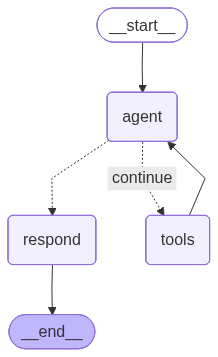

In [123]:
# VISUALIZE THE AGENT WORKFLOW
# Generate a visual representation of the agent's decision flow and state transitions

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Testing the SQL Agent

Now let's create helper functions to test our agent and then demonstrate it with some example queries.

In [124]:
# HELPER FUNCTIONS FOR TESTING THE SQL AGENT
# Utility functions to start conversations and process questions

import uuid

def start_conversation():
    """
    Initialize a new conversation with a unique thread ID.
    
    Returns:
        Configuration dictionary with thread ID and recursion limit
        The recursion limit prevents infinite loops in the agent workflow
    """
    thread_id = uuid.uuid4()
    print(f'Thread ID: {thread_id}')
    return {"configurable": {"thread_id": thread_id}, 'recursion_limit': 150}


def answer_question(query, config):
    """
    Process a natural language question using the SQL agent.
    
    This function:
    1. Displays the user's question
    2. Invokes the agent workflow to process the query
    3. Extracts and displays the final answer
    4. Returns the structured response
    
    Args:
        query: Natural language question about the database
        config: Configuration with thread ID and limits
        
    Returns:
        QueryResponse object containing the formatted answer
    """
    print('### Question ###')
    print(query)
    
    # Create a fresh conversation configuration
    config = start_conversation()
    
    # Invoke the agent workflow with the user's question
    answer = graph.invoke(
        input={"messages": [("human", query)]}, 
        config=config
    )["final_response"]
    
    print('### Answer ###')
    prettyprint(answer.answer)
    
    return answer

### Example Query: Count Artists

In [125]:
question = "Total number of artist in the db?"
config = start_conversation()
answer = answer_question(question, config)

Thread ID: 771b9fc4-39dc-4102-967b-fa437a422120
### Question ###
Total number of artist in the db?
Thread ID: c04394da-98bd-4449-b531-be95b5ad51e6


response: content="<think>\nOkay, let's see. The user is asking for the total
number of artists in the database. First, I need to figure out which table
contains artist information. Since I'm not sure, I should start by listing all
the tables in the database using the sql_db_list_tables function. That will give
me an idea of what tables are available.\n\nOnce I have the list of tables, I
can check the schema of the relevant table(s) using sql_db_schema. The artist
table is likely named something like 'artists' or 'artist'. After identifying
the correct table, I can then write a SQL query to count the number of entries
in that table. The query would be SELECT COUNT(*) FROM artists. But before
executing, I should use sql_db_query_checker to make sure the query is correct.
If there's an error, I'll need to adjust the query based on the feedback.
Finally, once the query is verified, I can run it with sql_db_query to get the
total count.\n</think>\n\n" additional_kwargs={} response_metadata

### Example Query: Check which albums are most popular

In [126]:
question = "Which albums are the most popular?"
config = start_conversation()
answer = answer_question(question, config)

Thread ID: 0942d2e3-4156-46e3-a38b-d0480a7a77ec
### Question ###
Which albums are the most popular?
Thread ID: de29810d-bb45-4538-adfb-bbe9cccd7686
response: content="<think>\nOkay, let's see. The user is asking which albums are
the most popular. To figure that out, I need to look into the database structure
first. I should start by listing all the tables available using the
sql_db_list_tables function. Once I know the tables, I can check their schemas
with sql_db_schema to see which ones have data related to album
popularity.\n\nAssuming there's an 'albums' table, maybe there's a 'popularity'
column or something similar. Alternatively, there might be a 'tracks' table that
references albums and has play counts or other metrics. If there's a 'playlists'
table linking tracks to albums, that could also indicate popularity through the
number of playlist inclusions.\n\nAfter identifying the relevant tables and
columns, I'll construct a query to aggregate the data. For example, joining the
a

### Example Query: Complex multi-step question 

In [127]:
question = """Segment customers by purchase behavior (frequency, total spend, average order
  value)"""

config = start_conversation()
answer = answer_question(question, config)

Thread ID: 714263f2-5029-4dc4-8072-c72ee90e46c6
### Question ###
Segment customers by purchase behavior (frequency, total spend, average order
  value)
Thread ID: 24a89e94-b84c-4fc6-afbe-a036713399e4
response: content="<think>\nOkay, let's tackle this problem. The user wants to
segment customers based on their purchase behavior, specifically looking at
frequency, total spend, and average order value. First, I need to figure out
what tables and columns are available in the database. \n\nI'll start by using
the sql_db_list_tables function to get a list of all tables. Once I have that, I
can check the schema of the relevant tables, probably the customers and orders
tables. Using sql_db_schema, I can see what columns are available. For example,
the customers table might have customer_id, name, etc., and the orders table
might have order_id, customer_id, order_date, total_amount, etc.\n\nNext, I need
to calculate the required metrics. Frequency would be the count of orders per
customer. Tot

## Summary and Next Steps

This notebook demonstrated how to build an intelligent SQL agent using LangGraph that can:

### Key Capabilities Demonstrated
- **Natural Language Processing**: Converts user questions into appropriate SQL queries
- **Safe Database Interaction**: Prevents destructive operations while enabling data exploration
- **Automated Schema Discovery**: Intelligently explores database structure before querying
- **Query Validation**: Double-checks SQL syntax before execution to prevent errors
- **Structured Response Generation**: Returns consistent, well-formatted answers

### Agent Workflow Summary
1. **Question Analysis**: Agent analyzes the natural language question
2. **Schema Discovery**: Lists tables and examines relevant schemas automatically
3. **Query Construction**: Builds appropriate SQL queries based on the question and schema
4. **Validation & Execution**: Validates queries before execution and handles errors gracefully
5. **Response Formatting**: Converts query results back into natural language answers

Next I will implement a SQL-querying agent with customized tool calls.